In [1]:
import torch.nn as nn
from black_scholes.sobolev.bs_sobolev_nd import BlackScholesSobolevMultiAsset
from utility.model import EarlyStopping, ModelConfig
from config.bs_sobolev_nd import *

Training model with seed 42...
Iter      0 | Train: 9.8852e-01 | Val: 1.3582e+00 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter    500 | Train: 9.8307e-03 | Val: 1.7788e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   1000 | Train: 9.0851e-03 | Val: 1.2472e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   1500 | Train: 7.3449e-03 | Val: 9.8674e-03 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   2000 | Train: 5.7633e-03 | Val: 7.5756e-03 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   2500 | Train: 4.8631e-03 | Val: 7.9253e-03 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   3000 | Train: 4.9186e-03 | Val: 6.8298e-03 | Weights: J2=0.130  J3=0.341  pde=0.471  J4=0.059
Iter   3500 | Train: 4.1861e-03 | Val: 7.1479e-03 | Weights: J2=0.130  J3=0.341  pde=0.471  J4=0.059
Iter   4000 | Train: 4.2191e-03 | Val: 8.4340e-03 | Weights: J2=0.275  J3=0.196  pde=0.471  J4=0.059
Iter   4500 | Train: 4.5170e-03 | Val: 6.8362e-03 | Weights:

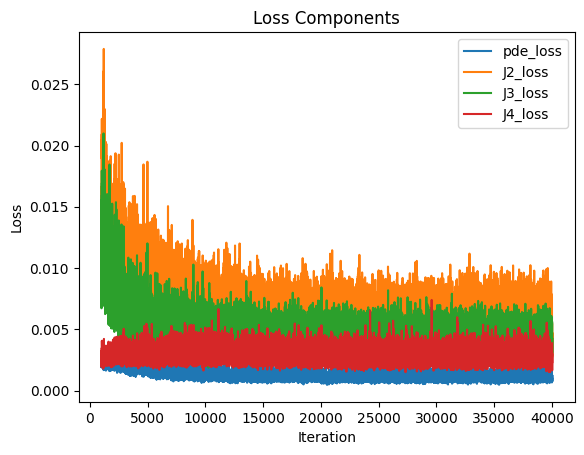

In [2]:
seed = 42
print(f'Training model with seed {seed}...')
pinn = BlackScholesSobolevMultiAsset(model_config, seed=seed)
pinn.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
pinn.set_loss_weights(loss_weights)
pinn.train(batch_size=4096, epochs=40000, early_stopping=None, anneal_freq=1000, alpha=0.9, causal_eps=2, fb_frac=0.65)
pinn.save(f'../../models/bs_sobolev_nd/{seed}.pth')
pinn.plot_losses(detailed=True, start_epoch=1000)

Training model with seed 14...
Iter      0 | Train: 9.0549e-01 | Val: 1.1946e+00 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter    500 | Train: 1.2043e-02 | Val: 2.6884e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   1000 | Train: 6.6000e-03 | Val: 1.4069e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   1500 | Train: 6.6599e-03 | Val: 1.3894e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   2000 | Train: 6.2831e-03 | Val: 1.0146e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   2500 | Train: 5.5215e-03 | Val: 9.8154e-03 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   3000 | Train: 4.6319e-03 | Val: 8.7218e-03 | Weights: J2=0.191  J3=0.279  pde=0.471  J4=0.059
Iter   3500 | Train: 5.0918e-03 | Val: 9.8329e-03 | Weights: J2=0.191  J3=0.279  pde=0.471  J4=0.059
Iter   4000 | Train: 4.3514e-03 | Val: 8.2820e-03 | Weights: J2=0.252  J3=0.219  pde=0.471  J4=0.059
Iter   4500 | Train: 4.0882e-03 | Val: 7.8736e-03 | Weights:

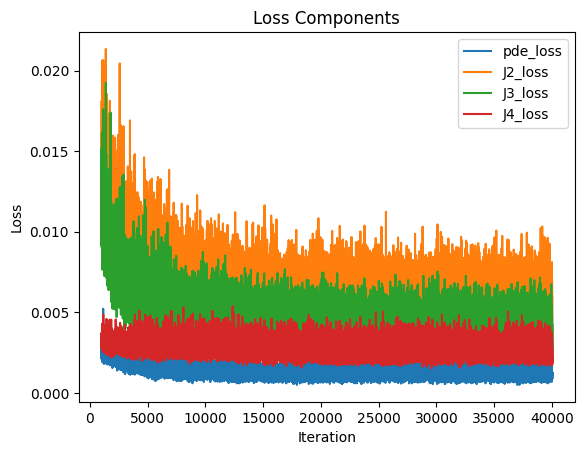

In [3]:
seed = 14
print(f'Training model with seed {seed}...')
model = BlackScholesSobolevMultiAsset(model_config, seed=seed)
model.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
model.set_loss_weights(loss_weights)
model.train(batch_size=4096, epochs=40000, early_stopping=None, anneal_freq=1000, alpha=0.9, causal_eps=1, fb_frac=0.5)
model.save(f'../../models/bs_sobolev_nd/{seed}.pth')
model.plot_losses(detailed=True, start_epoch=1000)